In [1]:
# ANN - Fashion MNIST Classification

# Problem Statement:
# Build an Artificial Neural Network (ANN) to classify images from the Fashion MNIST dataset into 10 different categories of clothing items.

# Fashion MNIST Dataset:
# The Fashion MNIST dataset consists of 70,000 grayscale images of 28x28 pixels, each representing a clothing item from 10 categories:
# 0: T-shirt/top
# 1: Trouser
# 2: Pullover
# 3: Dress
# 4: Coat
# 5: Sandal
# 6: Shirt
# 7: Sneaker
# 8: Bag
# 9: Ankle boot
# https://www.researchgate.net/profile/Greeshma-K-V/publication/340299295/figure/fig1/AS:875121904476163@1585656729996/Fashion-MNIST-Dataset-Images-with-Labels-and-Description-II-LITERATURE-REVIEW-In-image.jpg

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [3]:
# Load the Fashion MNIST dataset
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()


print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape:", x_test.shape, y_test.shape)

Training data shape: (60000, 28, 28) (60000,)
Testing data shape: (10000, 28, 28) (10000,)


In [4]:
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Labels:", labels)

Labels: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
labels[7]

'Sneaker'

In [6]:
print(x_train[0])  # each x train is a 28 * 28 matrix

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

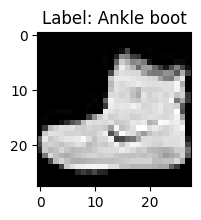

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {labels[y_train[0]]}") # image index=label index
#plt.axis('off')
plt.show()

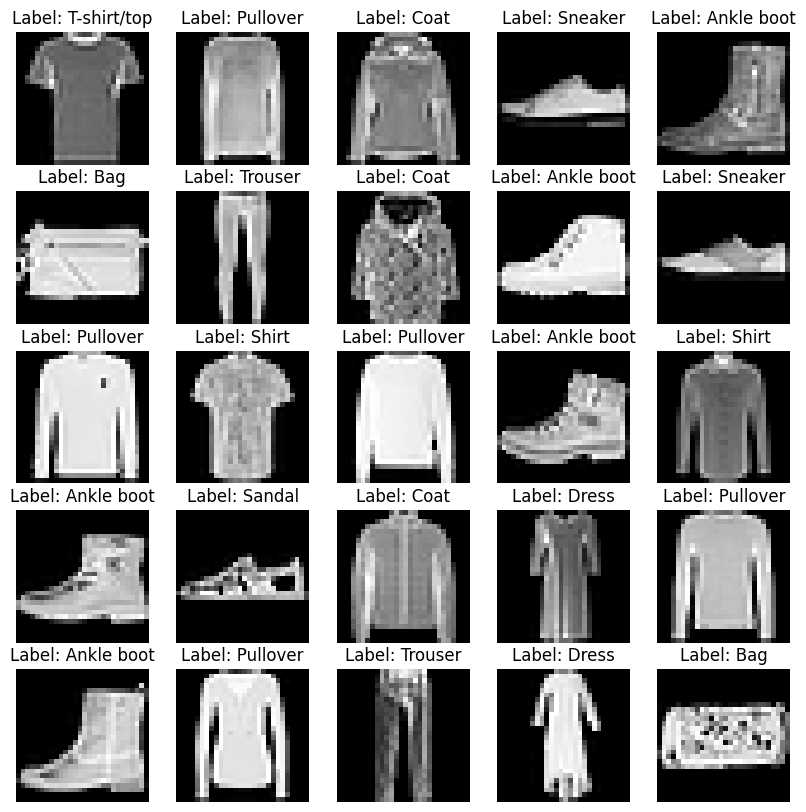

In [8]:
# Plot some sample images from the dataset along with their label names randomly
import random
plt.figure(figsize=(10,10))
for i in range(25):
    index = random.randint(0, len(x_train)-1)
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(f"Label: {labels[y_train[index]]}")
    plt.axis('off')
plt.show()

In [9]:
# Normalize the data
x_train = x_train / 255.0 # maximum pixel value is 255(grey) so we divide by 255 i.e (0,1) 
x_test = x_test / 255.0

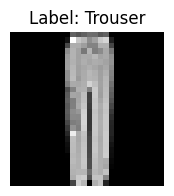

In [10]:
# Plot the image - 0th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[1000], cmap='gray')
plt.title(f"Label: {labels[y_train[1000]]}")
plt.axis('off')
plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(28, 28)))  # Input layer tells input size
model.add(Flatten())  # Flattening the 2D image to 1D vector
model.add(Dense(128, activation='relu'))  # First hidden layer with 128 neurons
model.add(Dense(256, activation='relu'))  # Second hidden layer with 256 neurons
model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons

# Input Layer: Accepts 28x28 pixel images. ==> Input Layer
# Hidden Layers ==> Dense Layers
# Output Layer ==> Dense Layer

# Activation Functions:
# 1. Input Layer: No activation function is applied here as it simply passes the input data to the next layer.
# 2. Hidden Layers: relu, leaky relu, elu, silu, gelu, selu, etc.
# 3. Output Layer: 
# a. Binary Classification: sigmoid
# b. Multi-class Classification: softmax
# c. Regression: linear

In [12]:
# Compiling a model = configuring how the neural network will learn.
# before training told to a model how to measure weight,loss,display metrices.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)  # Training the model for 10 epochs

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8252 - loss: 0.4833 - val_accuracy: 0.8468 - val_loss: 0.4106
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8677 - loss: 0.3591 - val_accuracy: 0.8466 - val_loss: 0.4373
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8806 - loss: 0.3251 - val_accuracy: 0.8636 - val_loss: 0.3780
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8870 - loss: 0.3032 - val_accuracy: 0.8781 - val_loss: 0.3373
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8943 - loss: 0.2825 - val_accuracy: 0.8762 - val_loss: 0.3423
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8974 - loss: 0.2695 - val_accuracy: 0.8786 - val_loss: 0.3507
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9028 - loss: 0.2581 - val_accuracy: 0.8830 - val_loss: 0.3336
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9064 - loss: 0.2478 -

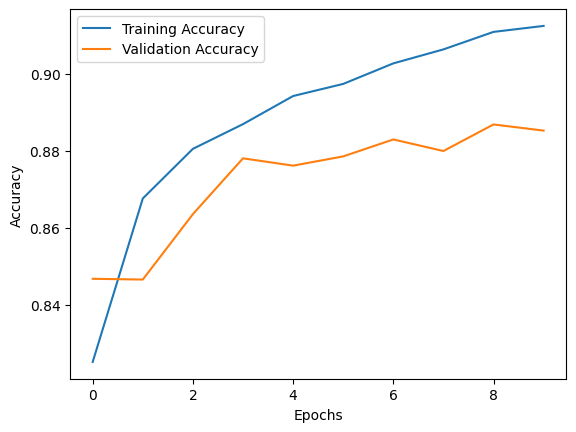

In [14]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [15]:
# The growing gap between them indicates the model is starting to overfit, meaning it learns training data better than unseen data.

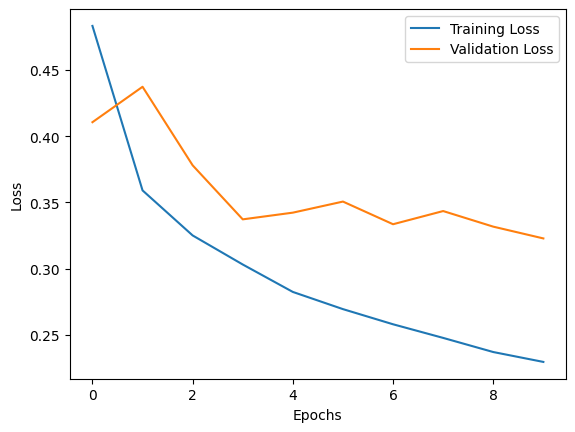

In [16]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [17]:
# It tests the trained model on unseen data
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.3229


[0.32287684082984924, 0.8852999806404114]

In [18]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8853 - loss: 0.3229
Loss: 0.32287684082984924
Accuracy: 0.8852999806404114


In [19]:
import numpy as np
y_pred = model.predict(x_test).argmax(axis=1) # out of all predicted probalties for each value it will provide us with highest one for  each label
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

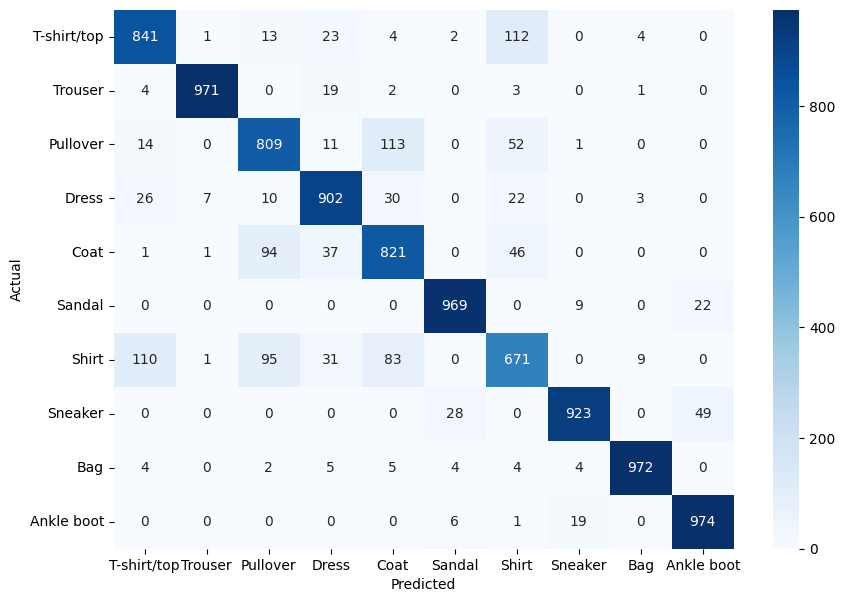

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_indices[:10]  # Print the first 10 misclassified indices

array([12, 17, 23, 25, 40, 42, 43, 49, 51, 57])

In [22]:
# Print the total number of misclassified images
print(f'Total misclassified images: {len(misclassified_indices)}')

Total misclassified images: 1147


In [ ]:
# impotance of plt.title using labels[y_test/y_predicted]

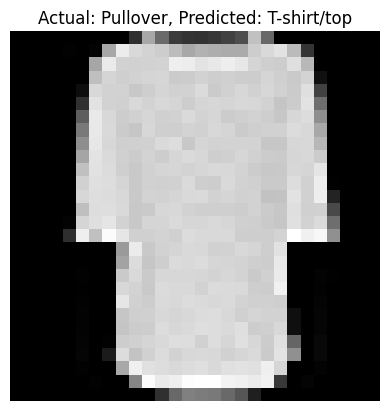

In [23]:
i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

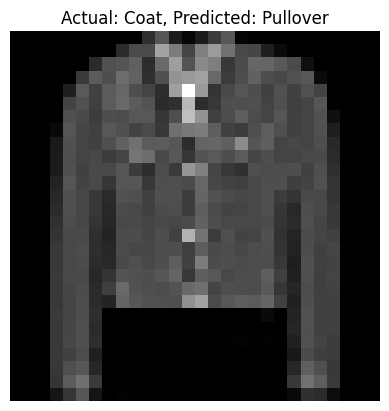

In [24]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

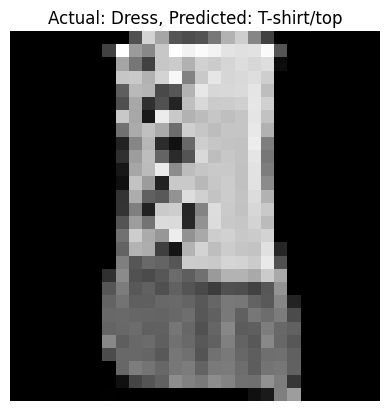

In [25]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

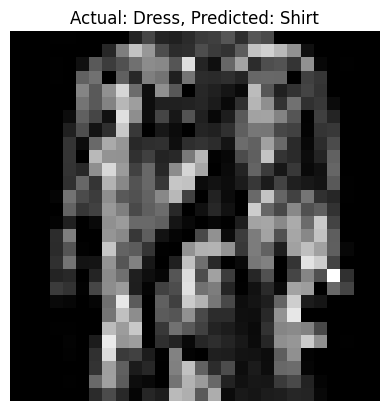

In [26]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

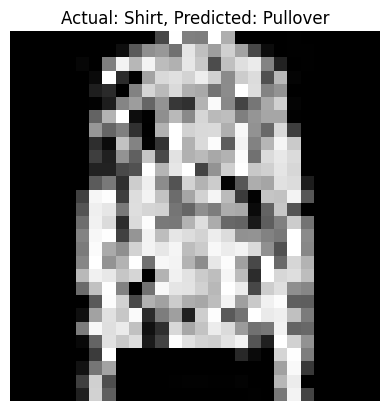

In [27]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

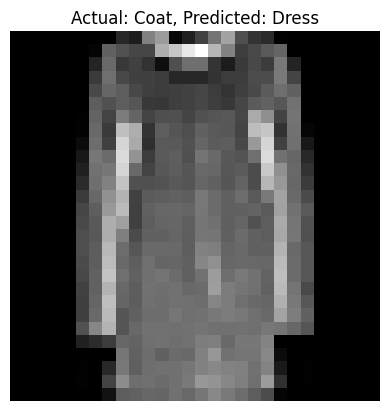

In [28]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

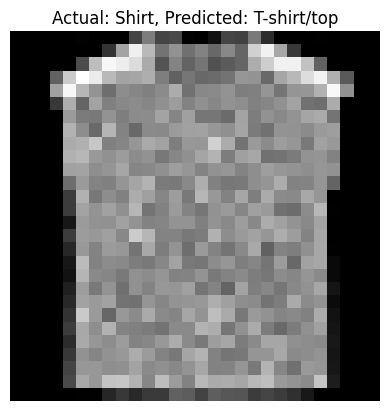

In [29]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

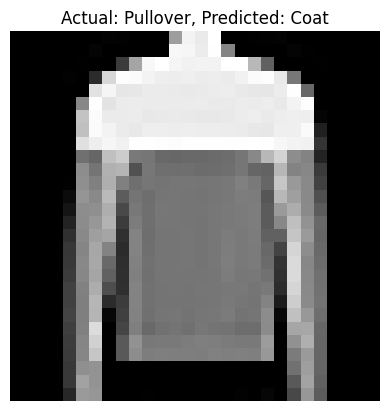

In [30]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

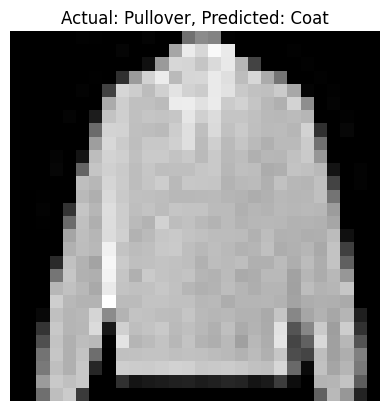

In [31]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

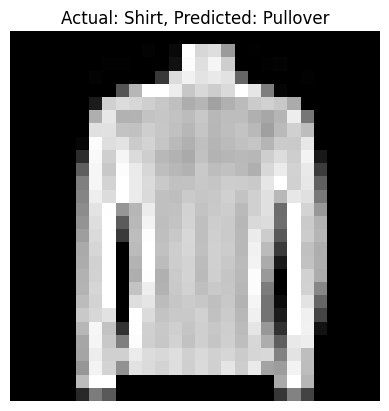

In [32]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

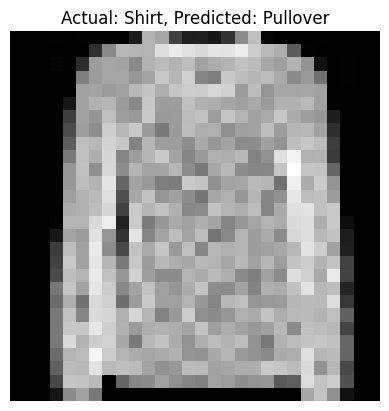

In [33]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()

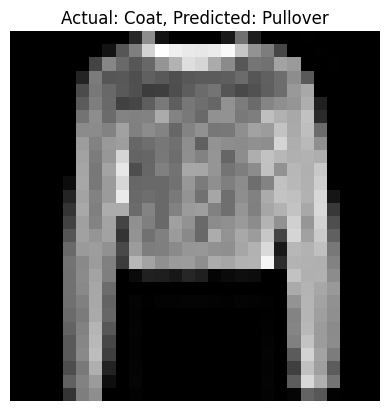

In [34]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.imshow(x_test[i], cmap='gray')
plt.title(f"Actual: {labels[y_test[i]]}, Predicted: {labels[y_pred[i]]}")
plt.axis('off')
plt.show()